In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [2]:
# Display settings
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/Smartphone_Usage_Productivity_Dataset_50000.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [5]:
# Data types
print("Data Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n")
df.describe()

Data Types:

User_ID                       object
Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

Missing Values:

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Summary Statistics:



,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


<h3> Target Variable Analysis

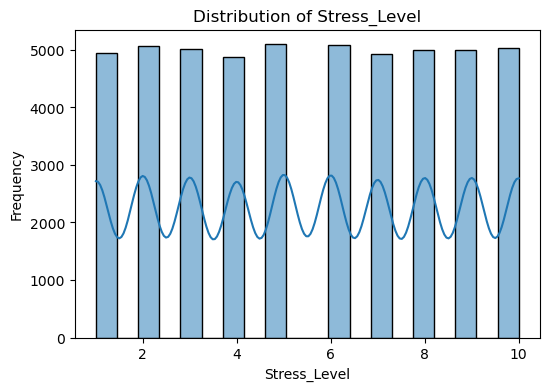

Skewness: -8.602366053324816e-05
Kurtosis: -1.22276142630973

Summary:
 count    50000.000000
mean         5.504500
std          2.871095
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Stress_Level, dtype: float64


In [6]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df["Stress_Level"], bins=20, kde=True)
plt.title("Distribution of Stress_Level")
plt.xlabel("Stress_Level")
plt.ylabel("Frequency")
plt.show()

# Statistical moments
stress_skew = skew(df["Stress_Level"])
stress_kurt = kurtosis(df["Stress_Level"])

print("Skewness:", stress_skew)
print("Kurtosis:", stress_kurt)
print("\nSummary:\n", df["Stress_Level"].describe())

<h3> Feature Distribution Diagnostics

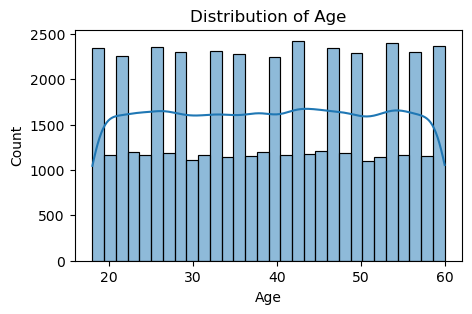

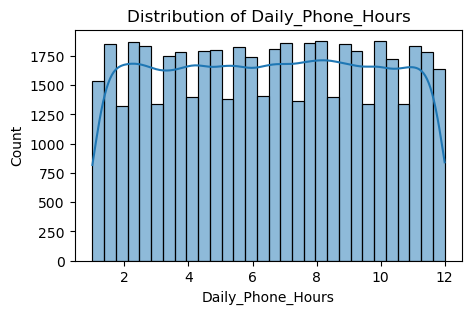

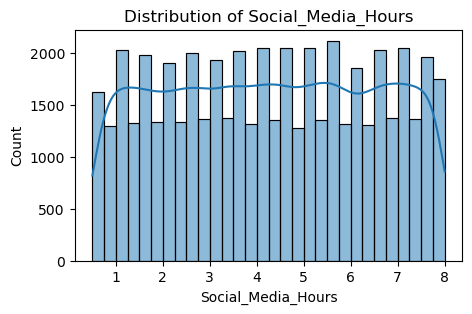

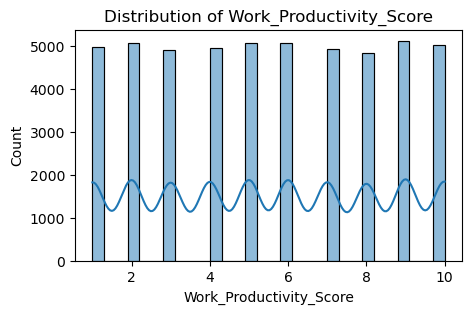

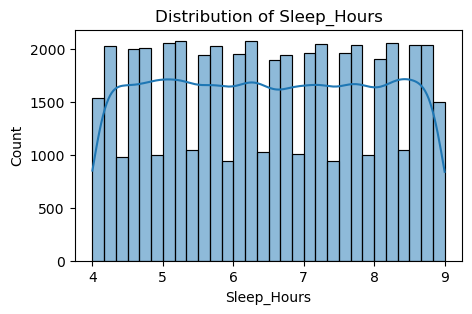

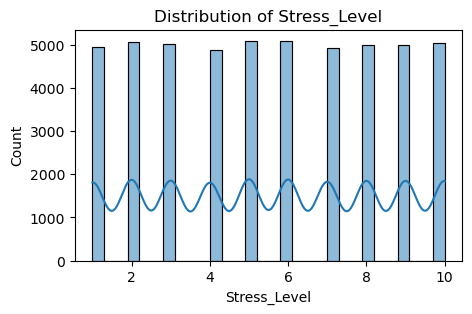

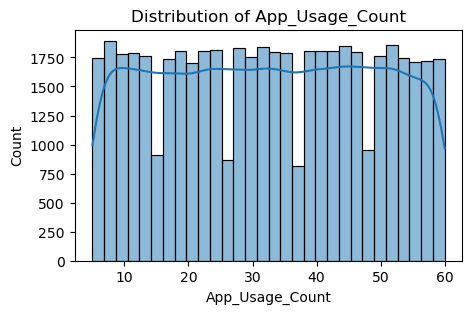

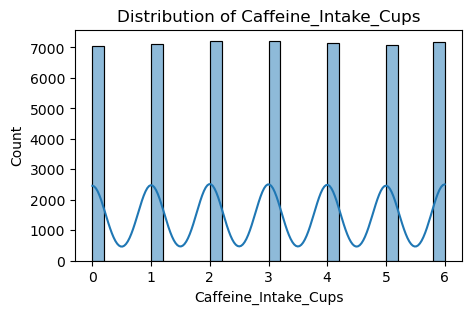

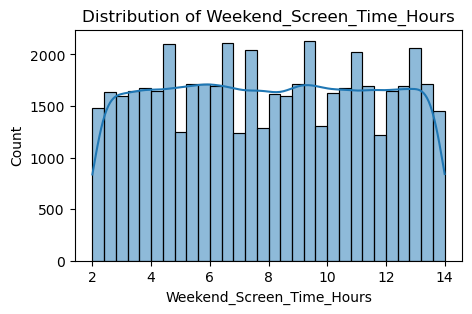

In [7]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

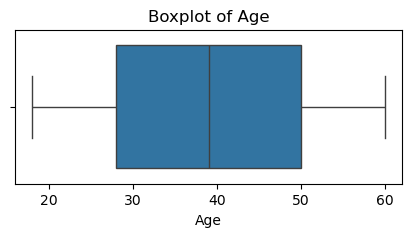

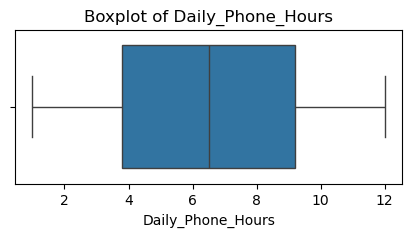

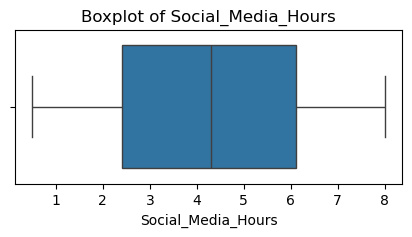

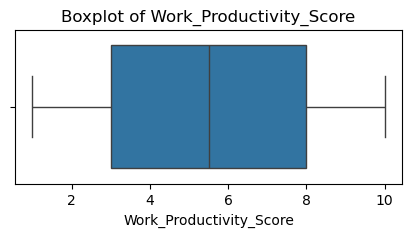

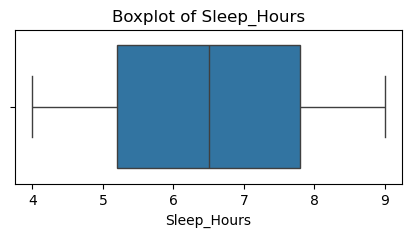

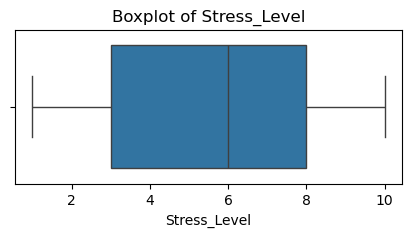

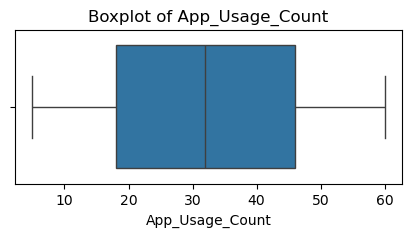

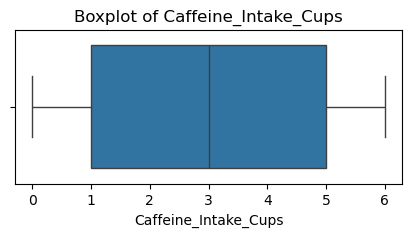

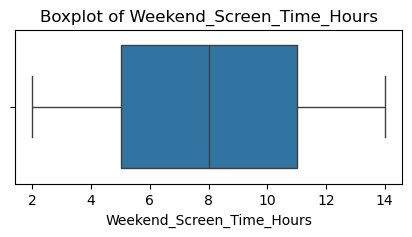

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<b> Insights </b>

<p> Since it's a synthetic data, its already balanced and has no outliers

<h3> Correlation Analysis

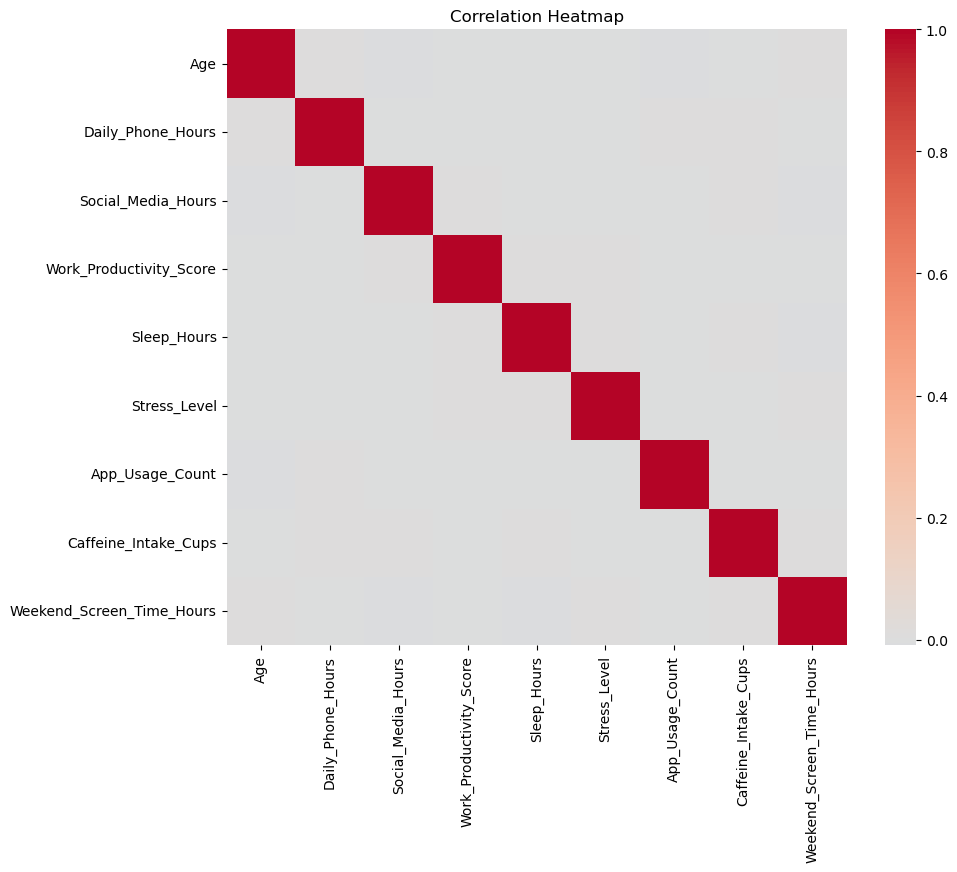

In [9]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Correlation with stress
stress_corr = corr_matrix["Stress_Level"].sort_values(ascending=False)

print("Correlation with Stress_Level:\n")
print(stress_corr)

Correlation with Stress_Level:

Stress_Level                 1.000000
Work_Productivity_Score      0.009786
Sleep_Hours                  0.004691
Weekend_Screen_Time_Hours    0.002671
Caffeine_Intake_Cups         0.001718
App_Usage_Count             -0.001272
Age                         -0.001512
Social_Media_Hours          -0.002721
Daily_Phone_Hours           -0.002762
Name: Stress_Level, dtype: float64


Top correlated features: Index(['Work_Productivity_Score', 'Sleep_Hours', 'Daily_Phone_Hours',
       'Social_Media_Hours'],
      dtype='object')


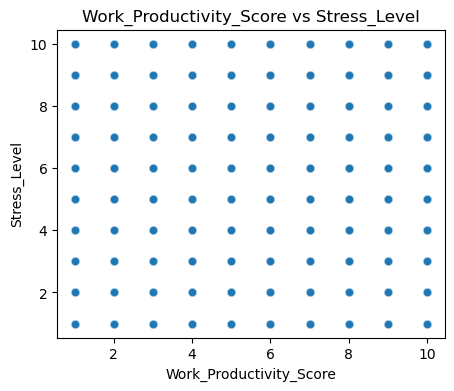

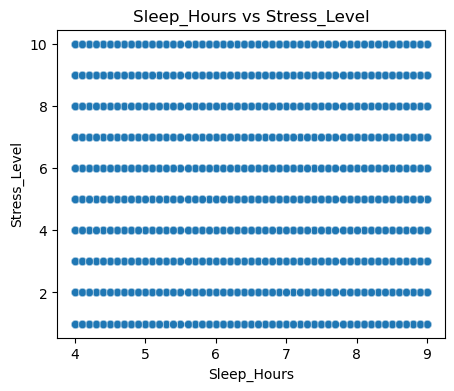

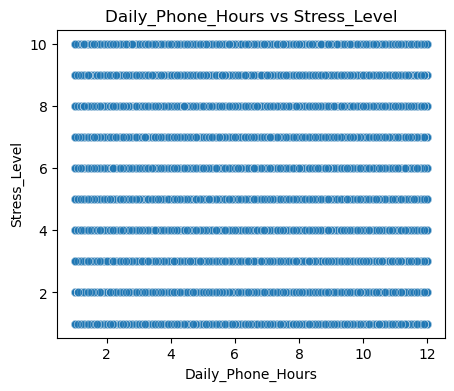

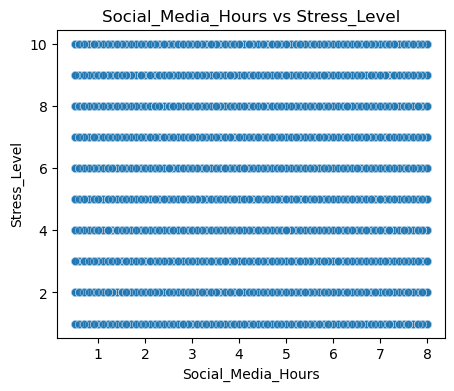

In [12]:
top_features = stress_corr.drop("Stress_Level").abs().sort_values(ascending=False).head(4).index

print("Top correlated features:", top_features)

for feature in top_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[feature], y=df["Stress_Level"], alpha=0.3)
    plt.title(f"{feature} vs Stress_Level")
    plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop target and ID
X = df[numeric_cols].drop(columns=["Stress_Level"])

# Add constant for VIF calculation
X_const = pd.concat([pd.Series(1, index=X.index, name="Intercept"), X], axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

vif_data

,Feature,VIF
0,Intercept,54.636650
1,Age,1.000209
2,Daily_Phone_Hours,1.000131
3,Social_Media_Hours,1.000205
4,Work_Productivity_Score,1.000072
5,Sleep_Hours,1.000085
6,App_Usage_Count,1.000118
7,Caffeine_Intake_Cups,1.000181
8,Weekend_Screen_Time_Hours,1.000171


In [14]:
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=["User_ID", "Gender", "Occupation", "Device_Type", "Stress_Level"])
y = df["Stress_Level"]

mi_scores = mutual_info_regression(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False)

mi_df

,Feature,Mutual_Information
4,Sleep_Hours,0.008234
6,Caffeine_Intake_Cups,0.003319
2,Social_Media_Hours,0.002509
1,Daily_Phone_Hours,0.002499
5,App_Usage_Count,0.000516
0,Age,0.000000
3,Work_Productivity_Score,0.000000
7,Weekend_Screen_Time_Hours,0.000000


In [15]:
corr_matrix["Work_Productivity_Score"].sort_values(ascending=False)

Work_Productivity_Score      1.000000
Stress_Level                 0.009786
Social_Media_Hours           0.003625
Sleep_Hours                  0.003243
Caffeine_Intake_Cups         0.001253
App_Usage_Count              0.001125
Daily_Phone_Hours           -0.002404
Age                         -0.003480
Weekend_Screen_Time_Hours   -0.005343
Name: Work_Productivity_Score, dtype: float64